<!-- Could you make one additional figure: 1 non-converter, 1 converter, and all survival curves for n=200 and n=30000 and frozen/fine-tuned (so 2x2x2)? -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from curve_utils import get_all_curves, draw_curves
import pandas as pd
import numpy as np
import pickle
import os

In [3]:
# log_dir = '/home/berens/bep973/ifeoma_home/leverage-data/log_dir'
# CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
# CHKPT_DIR= chkpt_dir ='/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/checkpoints/npj_june_areds'
# root_dir = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds/datasets'
# stylef = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/utils/berenslab.mplstyle'
# RESULTS_DIR = '/home/berens/bep973/ifeoma_home/leverage-data/results'
# csv_dir = os.path.dirname(root_dir)
# print(csv_dir)
# split_id = 11042026

In [41]:
from omegaconf import OmegaConf
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
metadata_dir = f'{project_dir}/metadata'
CLEANED_FILE= 'areds_new_results_cleaned_03_06_26_split_id_11042026'
config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
img_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [40]:
!ls /gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula

R_1004	 R_51459  R_52864  R_54233  R_55660  R_57185  R_59291	R_60820
R_1010	 R_51465  R_52865  R_54235  R_55661  R_57186  R_59292	R_60827
R_1015	 R_51467  R_52866  R_54236  R_55662  R_57187  R_59293	R_60828
R_1023	 R_51477  R_52868  R_54237  R_55663  R_57188  R_59295	R_60829
R_1024	 R_51480  R_52869  R_54241  R_55664  R_57189  R_59304	R_60831
R_1032	 R_51481  R_5287   R_54242  R_55666  R_57190  R_59305	R_60832
R_1049	 R_51482  R_52870  R_54245  R_55667  R_57191  R_59306	R_60833
R_1053	 R_51488  R_52871  R_54246  R_55668  R_57192  R_59309	R_60837
R_1067	 R_51489  R_52872  R_54247  R_55670  R_57193  R_59311	R_60838
R_1068	 R_51491  R_52873  R_54250  R_55676  R_57194  R_59318	R_60839
R_1069	 R_51492  R_52874  R_54256  R_55677  R_57195  R_59320	R_60840
R_1073	 R_51500  R_52875  R_54257  R_55680  R_57196  R_59322	R_60845
R_1074	 R_51501  R_52876  R_54263  R_55681  R_57197  R_59330	R_60846
R_1082	 R_51505  R_52877  R_54264  R_55684  R_57198  R_59331	R_60851
R_1085	 R_51509  R_52878  R_54265 

## Prelim

In [5]:
surv_log_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}.csv'))
surv_log_df.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [6]:
ex1 = surv_log_df.iloc[0]
ex1

Name                   testrun_False_FE_False_100_linear_2026-06-15_1...
State                                                           finished
Notes                                                                  -
User                                                                 NaN
Tags                                                                 NaN
                                             ...                        
val/ibs                                                          0.08436
val/ibs_best                                                    0.084258
val/mean_auroc                                                  0.772707
val/mean_auroc_best                                             0.762622
summary                                                 simclr_inet_nako
Name: 0, Length: 71, dtype: object

In [7]:
log_file_path = os.path.join(chkpt_dir, ex1['Name'])
os.listdir(log_file_path)

['test_survival_curves.csv']

In [8]:
surv_curves = pd.read_csv(os.path.join(log_file_path, 'test_survival_curves.csv'))
surv_curves.head()

,survival_curve,event,duration,image_name
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg


In [9]:
surv_curves['ID'] = surv_curves['image_name'].apply(lambda x : x.split('_')[0])
surv_curves['visit_number'] = surv_curves['image_name'].apply(lambda x : x.split('_')[1])
surv_curves['image_side'] = surv_curves['image_name'].apply(lambda x : x.split('_')[-2])
surv_curves.head()

,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg,55353,06,LE
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg,55353,08,LE
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg,55353,10,LE
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg,55353,12,LE


In [10]:
surv_curves_plot = surv_curves[surv_curves['image_side']=='LE'].reset_index()
surv_curves_plot.head(1)

,index,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE


In [11]:
to_plot = surv_curves_plot.loc[10]
to_plot

index                                                            20
survival_curve    [0.97345673 0.95774227 0.94885854 0.93802622 0...
event                                                    tensor(1.)
duration                                                  tensor(0)
image_name                                    57209_04_F2_LE_LS.jpg
ID                                                            57209
visit_number                                                     04
image_side                                                       LE
Name: 10, dtype: object

In [12]:
s = surv_curves_plot.loc[10, 'survival_curve']
values = [float(x) for x in s.strip('[]').split()]
values

[0.97345673, 0.95774227, 0.94885854, 0.93802622, 0.92560254]

In [15]:
metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()


/tmp/ipykernel_719340/1998338933.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1001,1001_left,1001_left_RS_04,4,left,F2,RS,51685_04_F2_LE_RS.jpg,51685/51685_04_F2_LE_RS.jpg,3.0,...,4.0,N,N,6.0,N,74.4,1001_left,1001_left_4,16,0
1,1001,1001_left,1001_left_LS_06,6,left,F2,LS,51685_06_F2_LE_LS.jpg,51685/51685_06_F2_LE_LS.jpg,3.0,...,4.0,N,N,6.0,N,75.4,1001_left,1001_left_6,14,0
2,1001,1001_left,1001_left_LS_08,8,left,F2,LS,51685_08_F2_LE_LS.jpg,51685/51685_08_F2_LE_LS.jpg,2.0,...,4.0,N,N,6.0,N,76.4,1001_left,1001_left_8,12,0
3,1001,1001_left,1001_left_RS_10,10,left,F2,RS,51685_10_F2_LE_RS.jpg,51685/51685_10_F2_LE_RS.jpg,4.0,...,4.0,N,N,6.0,N,77.5,1001_left,1001_left_10,10,0
4,1001,1001_left,1001_left_LS_14,14,left,F2,LS,51685_14_F2_LE_LS.jpg,51685/51685_14_F2_LE_LS.jpg,6.0,...,4.0,N,N,6.0,N,80.1,1001_left,1001_left_14,6,0


In [16]:
patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(metadata_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,G617,G617_right,G617_right_RS_08,8,right,F2,RS,53179_08_F2_RE_RS.jpg,53179/53179_08_F2_RE_RS.jpg,5.0,...,4.0,N,N,6.0,Y,72.8,G617_right,G617_right_8,8,0
11138,G617,G617_right,G617_right_LS_10,10,right,F2,LS,53179_10_F2_RE_LS.jpg,53179/53179_10_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,73.8,G617_right,G617_right_10,6,0
11139,G617,G617_right,G617_right_LS_12,12,right,F2,LS,53179_12_F2_RE_LS.jpg,53179/53179_12_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,75.0,G617_right,G617_right_12,4,0
11140,G617,G617_right,G617_right_LS_14,14,right,F2,LS,53179_14_F2_RE_LS.jpg,53179/53179_14_F2_RE_LS.jpg,8.0,...,4.0,N,N,6.0,Y,76.0,G617_right,G617_right_14,2,0


In [17]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()

n_img
10    273
1     246
9     243
8     171
5     144
4     139
6     135
11    108
7     108
2      94
3      83
12     12
Name: count, dtype: int64

In [18]:
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()

has_event
False    1368
True      388
Name: count, dtype: int64

In [19]:
sample0_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = 13#random.randint(0,(len(sample_)-1))\n",
print(num0)

13


In [20]:
all_images_to_plot0 =  sample0_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot0

image_path             [4074/4074_00_RE_F2_LS.jpg, 4074/4074_04_RE_F2...
diagnosis_amd_grade                           [6.0, 7.0, 7.0, 7.0, 11.0]
patient_id                                [4074, 4074, 4074, 4074, 4074]
visit_number                                            [0, 4, 6, 8, 10]
Name: 13, dtype: object

## Plot

In [ ]:
import random

In [4]:
METADATA_CSV = os.path.join(root_dir,'surv_jul_data0_11_04_26.csv')
areds_df = pd.read_csv(METADATA_CSV)
df_ssl = areds_df.sort_values(['eye_id', 'visit_number']).groupby(['eye_id']).agg(list).reset_index()


/tmp/ipykernel_1872072/4165426703.py:2: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  areds_df = pd.read_csv(METADATA_CSV)


In [ ]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)



In [ ]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()
sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = random.randint(0,(len(sample_)-1))
print(num0)
all_images_to_plot0 =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot = all_images_to_plot0['image_path']
all_images_to_plot

In [ ]:
sample1_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == False)].reset_index(drop = False)
num1 = random.randint(0,(len(sample1_)-1))

In [76]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [59]:
dfl = or_df[(or_df['freeze_encoder'] == 1) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == 500)]
dfl_ssl = dfl.groupby(['weights_path']).agg(list)

dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
model_list = sorted(list(dfl_ssl['model'].unique()))
model_list
dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )

dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
dfl_ssl['best_result'].head()


weights_path
dino_meta          testrun_False_FE_True_500_mlp_2026-06-01_12-17-31
dino_nako          testrun_False_FE_True_500_mlp_2026-06-07_18-17-44
nako_mae           testrun_False_FE_True_500_mlp_2026-06-01_22-17-38
resnet_imagenet    testrun_False_FE_True_500_mlp_2026-06-09_15-10-33
retfound           testrun_False_FE_True_500_mlp_2026-06-01_07-02-54
Name: best_result, dtype: str

In [ ]:
curves_dict0= get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)


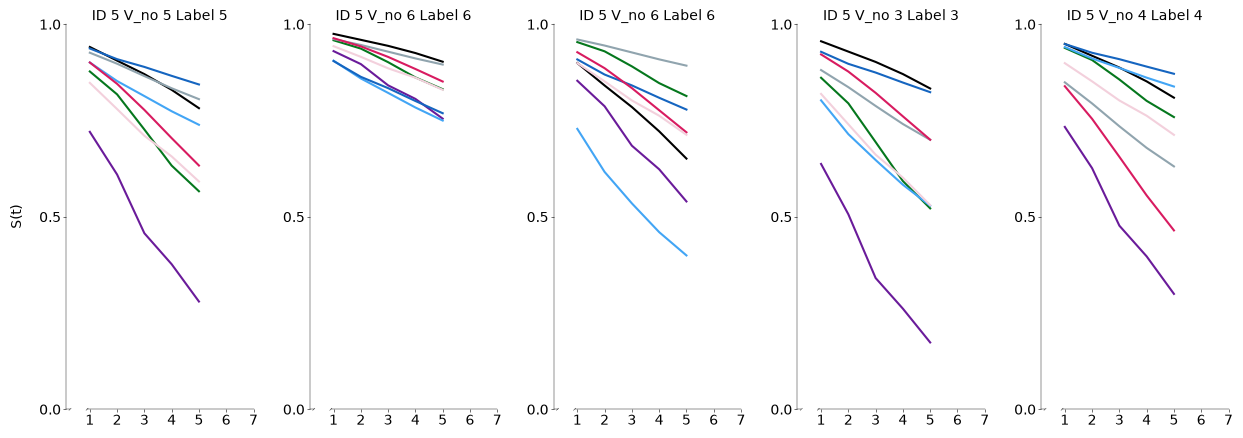

In [64]:
draw_curves(all_images_to_plot, 
            curves_dict0,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

In [65]:
all_images_to_plot

['56634/56634_04_F2_LE_RS.jpg',
 '56634/56634_06_F2_LE_LS.jpg',
 '56634/56634_08_F2_LE_LS.jpg',
 '56634/56634_10_F2_LE_LS.jpg',
 '56634/56634_12_F2_LE_RS.jpg']

Could you make one additional figure: 1 non-converter, 1 converter, 
and all survival curves for n=200 and n=30000 and frozen/fine-tuned (so 2x2x2)?

In [66]:
all_images_to_plot0 =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot = all_images_to_plot0['image_path']
all_images_to_plot

['56634/56634_04_F2_LE_RS.jpg',
 '56634/56634_06_F2_LE_LS.jpg',
 '56634/56634_08_F2_LE_LS.jpg',
 '56634/56634_10_F2_LE_LS.jpg',
 '56634/56634_12_F2_LE_RS.jpg']

In [67]:
all_images_to_plot1 =  sample1_.loc[num1, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot1 = all_images_to_plot1['image_path']
all_images_to_plot1

['58777/58777_04_F2_RE_RS.jpg',
 '58777/58777_06_F2_RE_LS.jpg',
 '58777/58777_08_F2_RE_LS.jpg',
 '58777/58777_10_F2_RE_RS.jpg',
 '58777/58777_12_F2_RE_RS.jpg']

In [ ]:
curves_dict0= get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)
curves_dict1= get_all_curves(all_images_to_plot1, model_list, dfl_ssl, CHKPT_DIR)

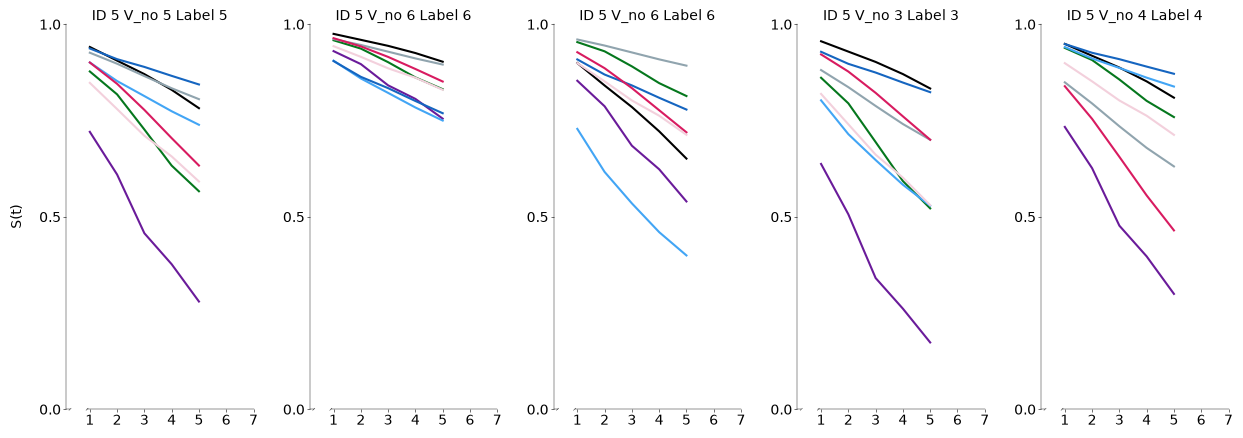

In [69]:
draw_curves(all_images_to_plot, 
            curves_dict0,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

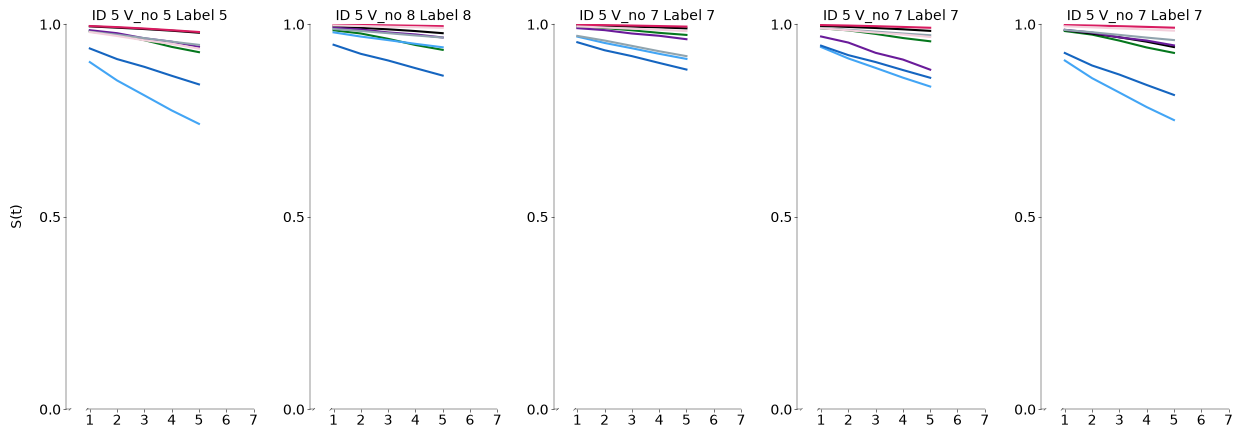

In [70]:
draw_curves(all_images_to_plot1, 
            curves_dict1,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

# Figure 6

In [26]:

import os
import random
import contextlib
import numpy as np
from argparse import ArgumentParser
from datetime import datetime
import pandas as pd
from pathlib import Path
import numpy as np
import os
from omegaconf import OmegaConf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from brokenaxes import brokenaxes
from matplotlib.legend_handler import HandlerLine2D
from curve_utils import plot_one_image_curve, plot_one_image_curve, draw_curves_all_patients, draw_curves_grid

In [27]:
metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(metadata_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test.head()

/tmp/ipykernel_719340/3305201377.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0


In [29]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}.csv'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


## Single

In [ ]:
dict1, img_to_plot = plot_one_image_curve(or_df, test, freeze_encoder = 1, train_size = 500, num_images = 2, CHKPT_DIR=CHKPT_DIR)

## Collective 

In [30]:
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': False},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': False},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 500, 'has_event': False},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': False},

            ]


In [ ]:
records = []

for i, vals in enumerate(info_dict):
    freeze_encoder = vals['freeze_encoder']
    train_size = vals['train_size']
    has_event = vals['has_event']

    dict1, img_to_plot, _= plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder,
        train_size=train_size, num_images=2, has_event=has_event,
        CHKPT_DIR=CHKPT_DIR#, num0=15
    )

    records.append({
        'freeze_encoder': freeze_encoder,
        'train_size': train_size,
        'has_event': has_event,
        'patient_id': img_to_plot['patient_id'][0] if isinstance(img_to_plot['patient_id'], list) else img_to_plot['patient_id'],
        'eye_id': img_to_plot['eye_id'][0] if isinstance(img_to_plot['eye_id'], list) else img_to_plot['eye_id'],
        'image_path': img_to_plot['image_path'][0] if isinstance(img_to_plot['image_path'], list) else img_to_plot['image_path'],
        'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'][0] if isinstance(img_to_plot['diagnosis_amd_grade'], list) else img_to_plot['diagnosis_amd_grade'],
        'visit_number': img_to_plot['visit_number'][0] if isinstance(img_to_plot['visit_number'], list) else img_to_plot['visit_number'],

        # 'image_path': img_to_plot['image_path'],
        # 'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'],
        # 'visit_number': img_to_plot['visit_number'],
        'curves': {model: curve[0] for model, curve in dict1.items()},  # unwrap the outer list
    })

### individual

In [ ]:
draw_curves_all_patients(full_data, full_curves_dict, save_path=RESULTS_DIR, stylef=stylef)

### grid

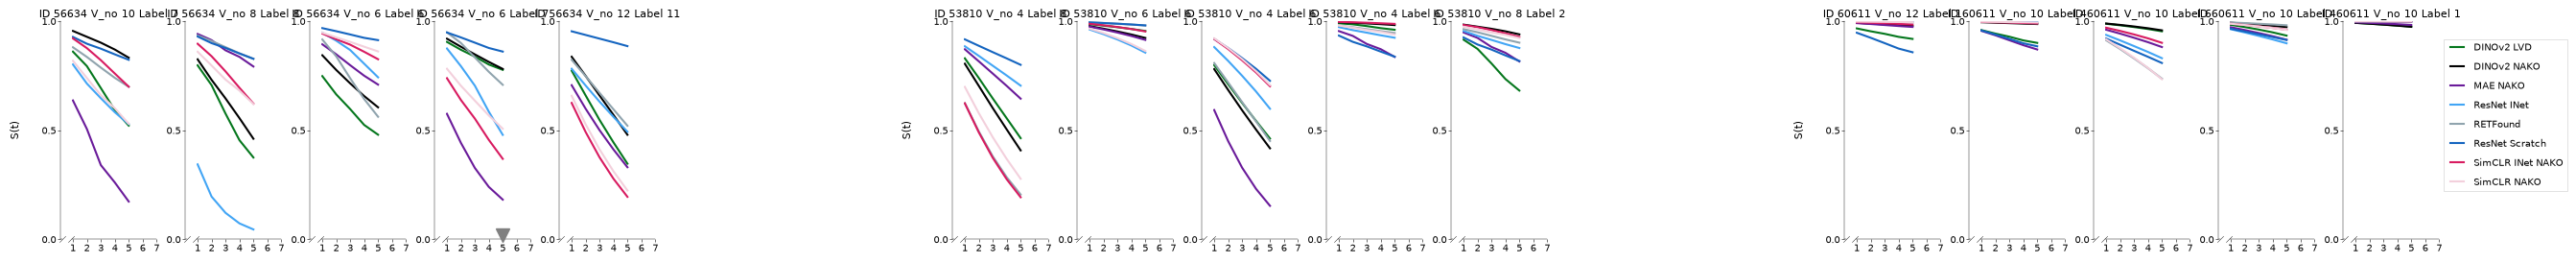

In [27]:
draw_curves_grid(full_data, full_curves_dict, n_per_patient=5,
                  n_rows=4, n_cols=4, save_path=RESULTS_DIR, stylef=stylef)

### master single

In [36]:
draw_curves_grid_simple(full_curves_dict, info_dict=info_dict, save_path=RESULTS_DIR, stylef=stylef)

NameError: name 'draw_curves_grid_simple' is not defined

### master all

In [37]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}

In [51]:
def draw_curves_grid_simple(records, image_dir=None, show_images=False,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    n_patients = len(records)
    print(records[0]['curves'])
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    with plt.style.context(stylef):
        if show_images:
            fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
                                          width_ratios=[1] * n_cols + [1.3],   # CHANGED: image col width now last
                                          wspace=0.2, hspace=0.6)
        else:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
            axes = axes.flatten()
             
        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            ax = fig.add_subplot(outer_gs[row, col_in_row]) if show_images else axes[p]  # CHANGED: no +1 shift

            for model, curve in rec['curves'].items():
                ax.plot(range(1, len(curve) + 1), curve,
                         label=new_names.get(model, model),
                         color=color_groups.get(model), linewidth=1.5)

            title = (f"pID {rec['patient_id']} eye_ID {rec['eye_id']}\n"
                     f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
            ax.set_title(title, fontsize=8)
            ax.set_ylim(y_min, y_max)
            ax.set_yticks([0, 0.5, 1])   # NEW

            ax.tick_params(axis='both', labelsize=7)
            if col_in_row == 0:
                ax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('Year', fontsize=9)

            if show_images and col_in_row == n_cols - 1:
                img_gs = gridspec.GridSpecFromSubplotSpec(
                    2, 2, subplot_spec=outer_gs[row, n_cols], wspace=0.05, hspace=0.05  # CHANGED: image block now at col n_cols
                )
                row_records = records[row * n_cols: row * n_cols + n_cols]
                for k, r in enumerate(row_records):
                    img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
                    img_path = os.path.join(image_dir, f"R_{r['image_path']}")
                    img_ax.imshow(Image.open(img_path))
                    img_ax.axis('off')

        if not show_images:
            for j in range(n_patients, len(axes)):
                axes[j].axis('off')

        # legend_ax = axes[0] if not show_images else fig.axes[0]
        # handles, labels = legend_ax.get_legend_handles_labels()
        # fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
        # plt.tight_layout()
        
        legend_ax = axes[0] if not show_images else fig.axes[0]
        handles, labels = legend_ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)
        plt.tight_layout()

        fig.subplots_adjust(bottom=0.15)  # adjust value as needed to fit the legend
# 
    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()


{'dino_meta': [0.99221989, 0.98807006, 0.98111283, 0.97305689, 0.96661075], 'dino_nako': [0.99713575, 0.99533124, 0.99348187, 0.99123799, 0.98847509], 'nako_mae': [0.98245546, 0.97363107, 0.95860482, 0.94864264, 0.93352452], 'resnet_imagenet': [0.91222269, 0.8691925, 0.83412278, 0.79854181, 0.76656453], 'retfound': [0.97986309, 0.97175546, 0.9624271, 0.95297263, 0.94430019], 'scratch': [0.96786591, 0.95338341, 0.94271344, 0.93027936, 0.91812809], 'simclr_inet_nako': [0.98645395, 0.97831692, 0.96772423, 0.95531425, 0.94214687], 'simclr_nako': [0.97598746, 0.96402784, 0.95089349, 0.93997567, 0.92563566]}


/tmp/ipykernel_719340/1581185630.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_719340/1581185630.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


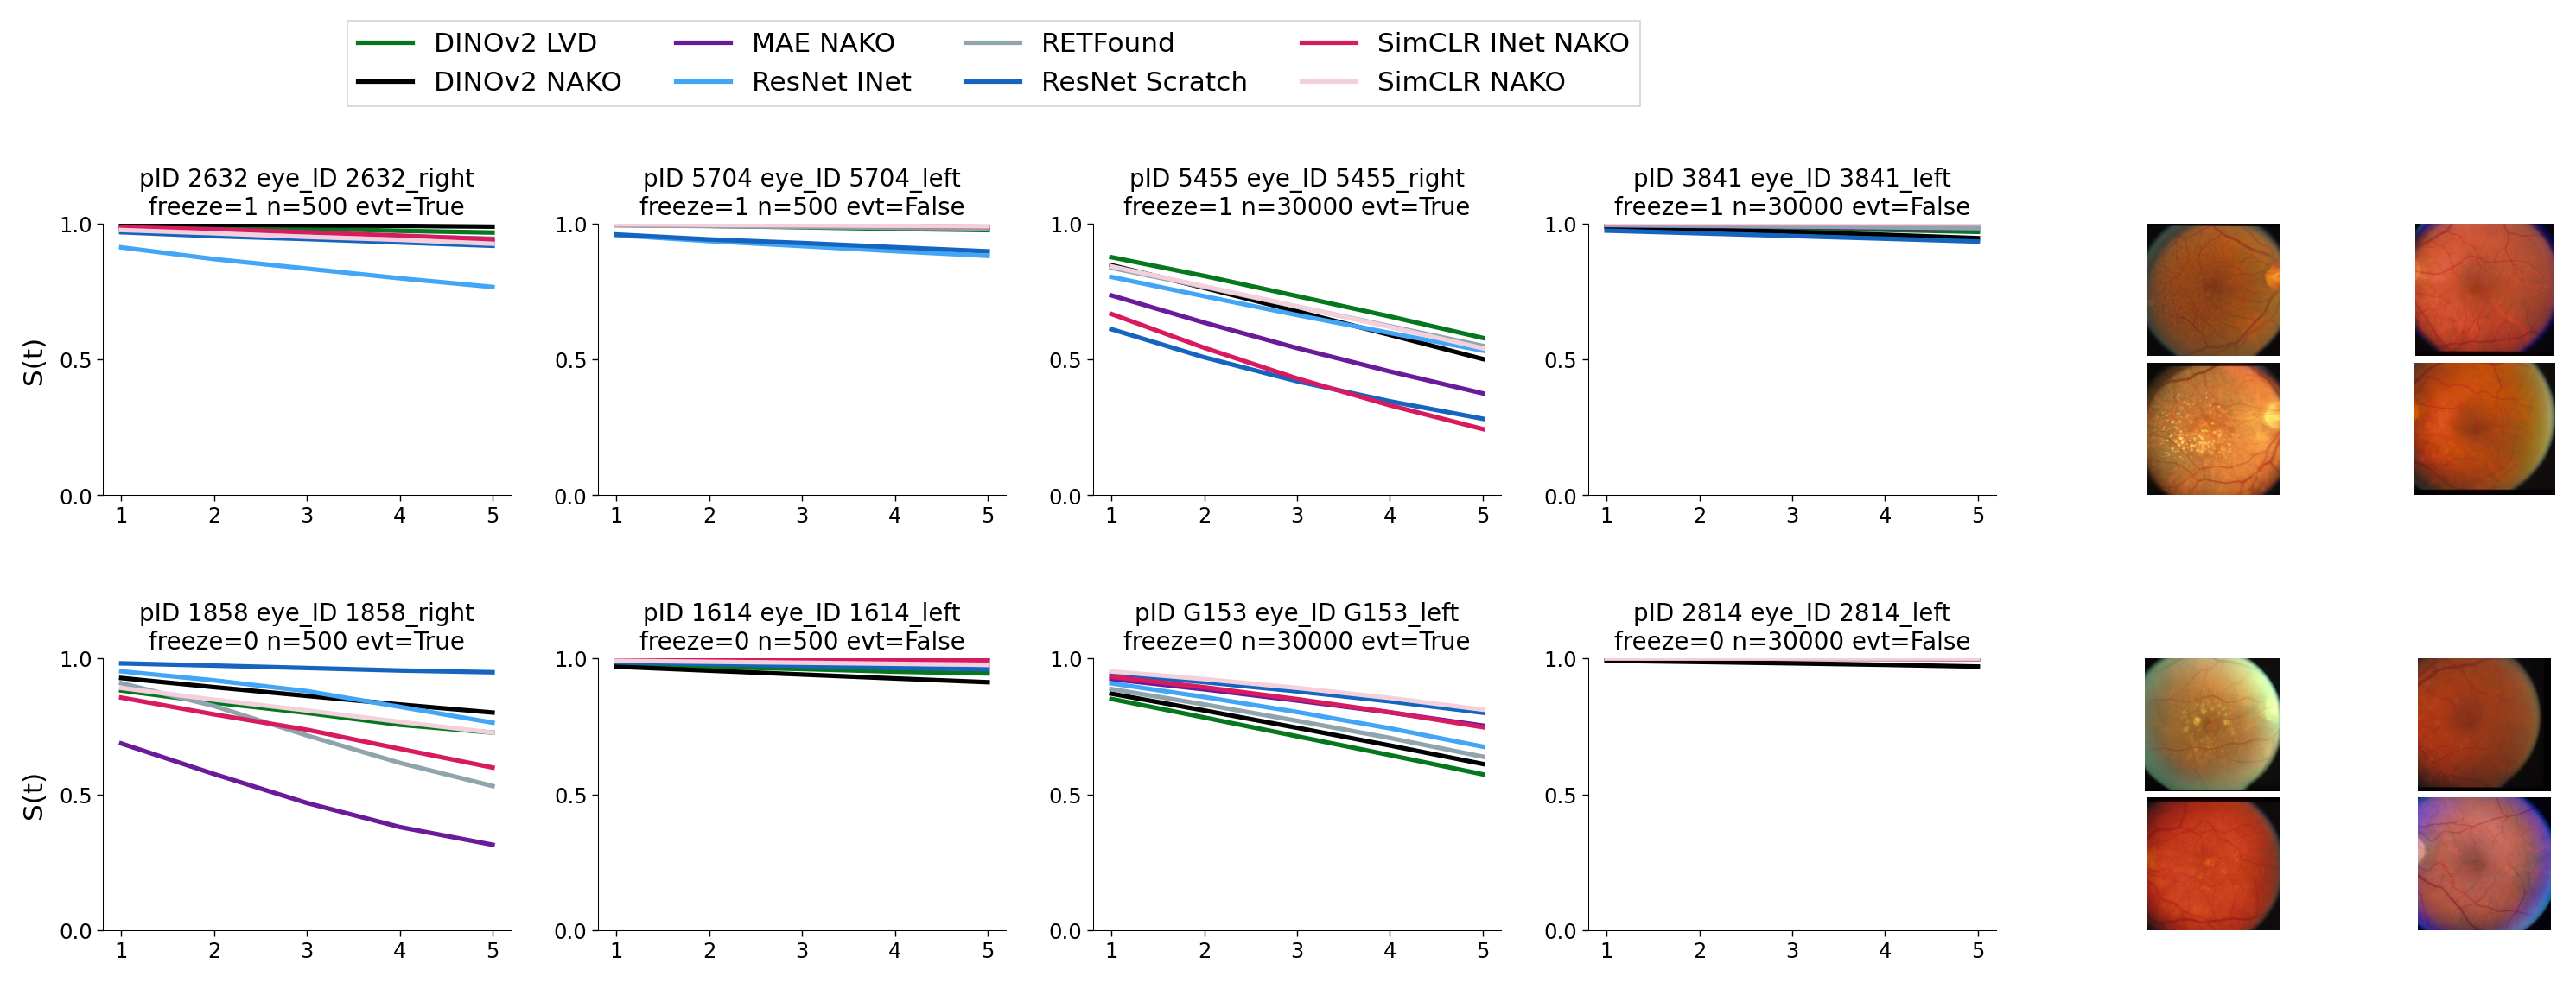

In [52]:
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)

In [15]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from PIL import Image

# color_groups = {
#     'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
#     'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
#     'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
# }
# new_names = {
#     'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
#     'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
#     'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
# }
# full_data = {'image_path': [], 'diagnosis_amd_grade': [], 'ID': [], 'visit_number': []}
# full_curves_dict = {}

# for i, vals in enumerate(info_dict):  # however you get the list of individuals in `test`
#     freeze_encoder = vals['freeze_encoder']
#     train_size = vals['train_size']
#     has_event = vals['has_event']

#     dict1, img_to_plot = plot_one_image_curve(
#         or_df, test, freeze_encoder=freeze_encoder, 
#         train_size=train_size, num_images=2, has_event=has_event,
#         CHKPT_DIR=CHKPT_DIR, num0=0 #i
#         # + whatever argument selects this specific patient, e.g. patient_id=patient_id
#     )

#     # Accumulate per-visit data
#     patient_id = img_to_plot['patient_id']
#     full_data['image_path'].extend(img_to_plot['image_path'])
#     full_data['diagnosis_amd_grade'].extend(img_to_plot['diagnosis_amd_grade'])
#     full_data['visit_number'].extend(img_to_plot['visit_number'])
#     # full_data['ID'].extend([patient_id] * len(img_to_plot['image_path']))
#     full_data['ID'].extend(patient_id)


#     # Accumulate per-model curves
#     for model, curve in dict1.items():
#         full_curves_dict.setdefault(model, []).extend(curve)

# def draw_curves_grid_simple(full_curves_dict, info_dict=None, ids=None,
#                              image_paths=None,          # NEW: list of one image path per patient
#                              show_images=False,         # NEW: flag
#                              n_rows=4, n_cols=4,
#                              save_path=None, stylef=None):
#     n_patients = len(next(iter(full_curves_dict.values())))
#     y_min = min(min(curve) for curves in full_curves_dict.values() for curve in curves) - 0.02
#     y_max = 1

#     with plt.style.context(stylef):
#         if show_images:
#             if image_paths is None:
#                 raise ValueError("show_images=True requires image_paths")

#             # +1 extra column on the left for the image block per row
#             fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
#             outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
#                                           width_ratios=[1.3] + [1] * n_cols,
#                                           wspace=0.4, hspace=0.6)
#         else:
#             fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
#             axes = axes.flatten()

#         for p in range(n_patients):
#             row, col_in_row = divmod(p, n_cols)

#             if show_images:
#                 ax = fig.add_subplot(outer_gs[row, col_in_row + 1])  # shift right by 1 for image col
#             else:
#                 ax = axes[p]

#             for model, curves in full_curves_dict.items():
#                 curve = curves[p]
#                 ax.plot(range(1, len(curve) + 1), curve,
#                          label=new_names.get(model, model),
#                          color=color_groups.get(model), linewidth=1.5)

#             title = f"Patient {ids[p]}" if ids is not None else f"Config {p}"
#             if info_dict is not None:
#                 cfg = info_dict[p]
#                 title += f"\nfreeze={cfg['freeze_encoder']} n={cfg['train_size']} evt={cfg['has_event']}"
#             ax.set_title(title, fontsize=8)
#             ax.set_ylim(y_min, y_max)
#             ax.tick_params(axis='both', labelsize=7)
#             if col_in_row == 0:
#                 ax.set_ylabel('S(t)', fontsize=9)
#             if row == n_rows - 1:
#                 ax.set_xlabel('Year', fontsize=9)

#             # ── draw the 2x2 image block once per row, after its 4th patient is placed ──
#             if show_images and col_in_row == n_cols - 1:
#                 img_gs = gridspec.GridSpecFromSubplotSpec(
#                     2, 2, subplot_spec=outer_gs[row, 0], wspace=0.05, hspace=0.05
#                 )
#                 row_start = row * n_cols
#                 row_paths = image_paths[row_start: row_start + n_cols]  # 4 images for this row
#                 for k, i_path in enumerate(row_paths):
#                     img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
#                     img_path = os.path.join(f"{img_dir}", f"R_{i_path}")
#                     img = Image.open(img_path)
#                     img_ax.imshow(img)
#                     img_ax.axis('off')

#         if not show_images:
#             for j in range(n_patients, len(axes)):
#                 axes[j].axis('off')

#         # shared legend
#         legend_ax = axes[0] if not show_images else fig.axes[-5]  # first curve axis
#         handles, labels = legend_ax.get_legend_handles_labels()
#         fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
#         plt.tight_layout()

#     if save_path is not None:
#         plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
#     plt.show()

# draw_curves_grid_simple(
#     full_curves_dict,
#     info_dict=info_dict,
#     image_paths=full_data['image_path'],   # one representative path per patient — see note below
#     show_images=True,
#     save_path=RESULTS_DIR,
#     stylef=stylef
# )

In [16]:
# def draw_curves_grid_simple(records, image_dir=None, show_images=False,
#                              n_rows=4, n_cols=4, save_path=None, stylef=None):
#     n_patients = len(records)
#     print(records[0]['curves'])
#     y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
#     y_max = 1

#     with plt.style.context(stylef):
#         if show_images:
#             fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
#             outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
#                                           width_ratios=[1.3] + [1] * n_cols,
#                                           wspace=0.4, hspace=0.6)
#         else:
#             fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
#             axes = axes.flatten()

#         for p, rec in enumerate(records):
#             row, col_in_row = divmod(p, n_cols)
#             ax = fig.add_subplot(outer_gs[row, col_in_row + 1]) if show_images else axes[p]

#             for model, curve in rec['curves'].items():
#                 ax.plot(range(1, len(curve) + 1), curve,
#                          label=new_names.get(model, model),
#                          color=color_groups.get(model), linewidth=1.5)

#             title = (f"ID {rec['patient_id']}\n"
#                      f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
#             ax.set_title(title, fontsize=8)
#             ax.set_ylim(y_min, y_max)
#             ax.tick_params(axis='both', labelsize=7)
#             if col_in_row == 0:
#                 ax.set_ylabel('S(t)', fontsize=9)
#             if row == n_rows - 1:
#                 ax.set_xlabel('Year', fontsize=9)

#             if show_images and col_in_row == n_cols - 1:
#                 img_gs = gridspec.GridSpecFromSubplotSpec(
#                     2, 2, subplot_spec=outer_gs[row, 0], wspace=0.05, hspace=0.05
#                 )
#                 row_records = records[row * n_cols: row * n_cols + n_cols]
#                 for k, r in enumerate(row_records):
#                     img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
#                     img_path = os.path.join(image_dir, f"R_{r['image_path']}")
#                     img_ax.imshow(Image.open(img_path))
#                     img_ax.axis('off')

#         if not show_images:
#             for j in range(n_patients, len(axes)):
#                 axes[j].axis('off')

#         legend_ax = axes[0] if not show_images else fig.axes[0]
#         handles, labels = legend_ax.get_legend_handles_labels()
#         fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
#         plt.tight_layout()

#     if save_path is not None:
#         plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
#     plt.show()

In [ ]:
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
import os
from PIL import Image

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}

def draw_curves_grid_simple(records, image_dir=None, show_images=False,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    n_patients = len(records)
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    with plt.style.context(stylef):
        # ── Build ONE figure + ONE grid layout, regardless of show_images ──
        if show_images:
            fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
                                          width_ratios=[1] * n_cols + [1.3],
                                          wspace=0.2, hspace=0.6)
        else:
            fig = plt.figure(figsize=(n_cols * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                                          wspace=0.3, hspace=0.6)

        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            cell = outer_gs[row, col_in_row]

            bax = brokenaxes(
                xlims=((-0.1, 0.002), (0.9, 5.1)),
                hspace=0.01, d=0.005, tilt=45,
                subplot_spec=cell,
                fig=fig
            )

            for model, curve in rec['curves'].items():
                bax.plot(range(1, len(curve) + 1), curve,
                          label=new_names.get(model, model),
                          color=color_groups.get(model), linewidth=1.5)

            title = (f"ID {rec['patient_id']}\n"
                      f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
            bax.set_title(title, fontsize=8)
            bax.set_ylim(y_min, y_max)
            bax.axs[1].set_yticks([0, 0.5, 1])
            bax.axs[0].set_xticks([])
            bax.axs[1].set_xticks([1, 2, 3, 4, 5])

            # restore visible left spine/ticks on the baseline mini-axis
            bax.axs[0].spines['left'].set_visible(True)
            bax.axs[0].tick_params(left=True, labelleft=True)

            for a in bax.axs:
                a.tick_params(axis='both', labelsize=7)

            if col_in_row == 0:
                bax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                bax.set_xlabel('Year', fontsize=9)

            # ── image block for this row, drawn once after last curve column ──
            if show_images and col_in_row == n_cols - 1:
                img_gs = gridspec.GridSpecFromSubplotSpec(
                    2, 2, subplot_spec=outer_gs[row, n_cols], wspace=0.05, hspace=0.05
                )
                row_records = records[row * n_cols: row * n_cols + n_cols]
                for k, r in enumerate(row_records):
                    img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
                    img_path = os.path.join(image_dir, f"R_{r['image_path']}")
                    img_ax.imshow(Image.open(img_path))
                    img_ax.axis('off')

        # ── One shared legend, built independently of any specific axis ──
        handles = [plt.Line2D([0], [0], color=color_groups[m], linewidth=1.5) for m in color_groups]
        labels = [new_names[m] for m in color_groups]
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)

        plt.tight_layout()
        fig.subplots_adjust(bottom=0.15)

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_3347640/121207866.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3347640/121207866.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


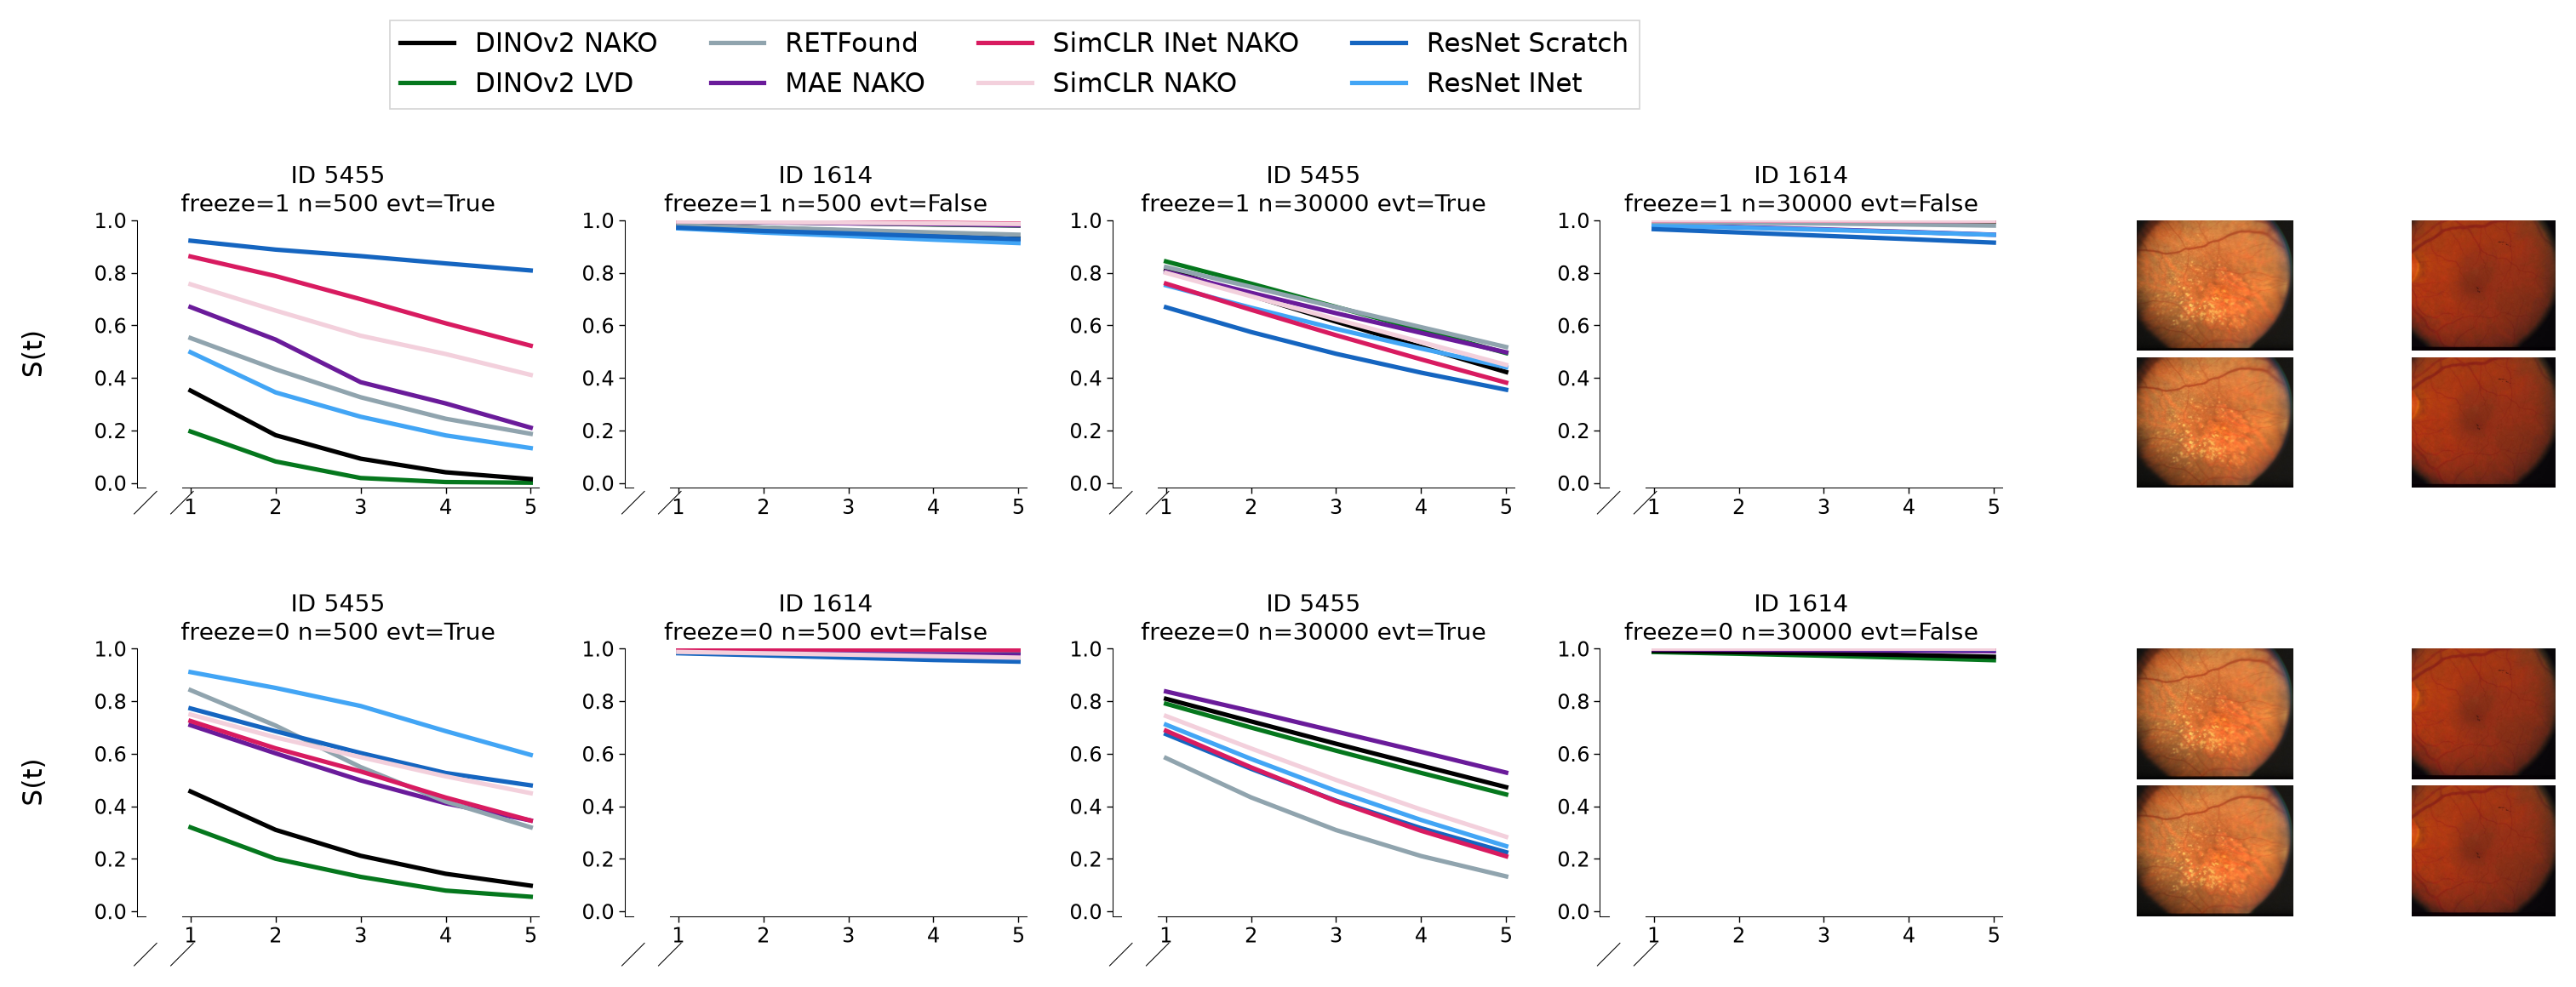

In [44]:
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)